# 18 — Spike Metrics × Food & Housing Insecurity

**Purpose**: Test whether food/housing insecurity predicts worse glucose variability
and spiking — not just mean glucose. NB12 found null at the mean level overall, but
a significant interaction by study group (insecure = *lower* glucose in medicated groups).
Spike metrics may reveal a different signal. This notebook also checks whether that
NB12 reversal pattern replicates when using spike outcomes instead of mean glucose.

**Inputs**: `17_spike_metrics_per_person.csv`, `features_with_cluster.csv` (Google Drive)

**Output**: `18_insecurity_spike_summary.csv`

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.
No Azure connection needed.

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['scipy', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_PAL   = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))

print('Environment ready.')

Environment ready.


In [3]:
# ── 2. Google Drive Mount ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {out_dir}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [4]:
# ── 3. Load Data & Merge ───────────────────────────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
spike_df  = pd.read_csv(out_dir / '17_spike_metrics_per_person.csv')

features['person_id'] = features['person_id'].astype(str)
spike_df['person_id']  = spike_df['person_id'].astype(str)
df = features.merge(spike_df, on='person_id', how='inner')

if 'study_group_label' not in df.columns:
    df['study_group_label'] = df['study_group_code'].map(STUDY_GROUP_MAP)
df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

df['insecurity_label'] = df['food_housing_insecurity'].map(
    {0.0: 'Food/Housing Secure', 1.0: 'Food/Housing Insecure'})
INSEC_ORDER = ['Food/Housing Secure', 'Food/Housing Insecure']
INSEC_PAL   = {'Food/Housing Secure': '#4daf4a', 'Food/Housing Insecure': '#e41a1c'}

SPIKE_COLS = [
    'spike_count', 'spike_count_250', 'spike_duration_mean', 'spike_area',
    'spike_peak_mean', 'tir', 'tar_180', 'tar_250', 'tbr_70',
    'glucose_sd', 'glucose_cv', 'mage'
]

print(f'Dataset: {len(df)} participants')
print(f'Insecurity rate: {df["food_housing_insecurity"].mean()*100:.1f}%')
print(df['insecurity_label'].value_counts())

Dataset: 2243 participants
Insecurity rate: 60.7%
insecurity_label
Food/Housing Insecure    1362
Food/Housing Secure       881
Name: count, dtype: int64


## 4. Distribution Analysis: Primary Spike Metrics × Insecurity

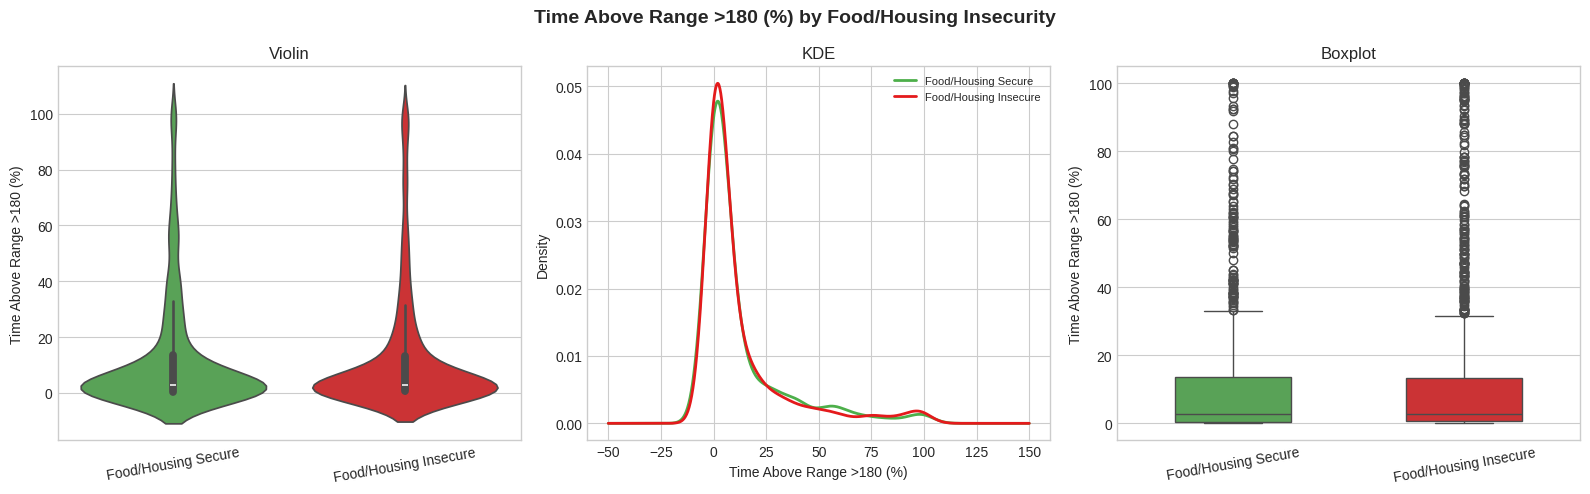

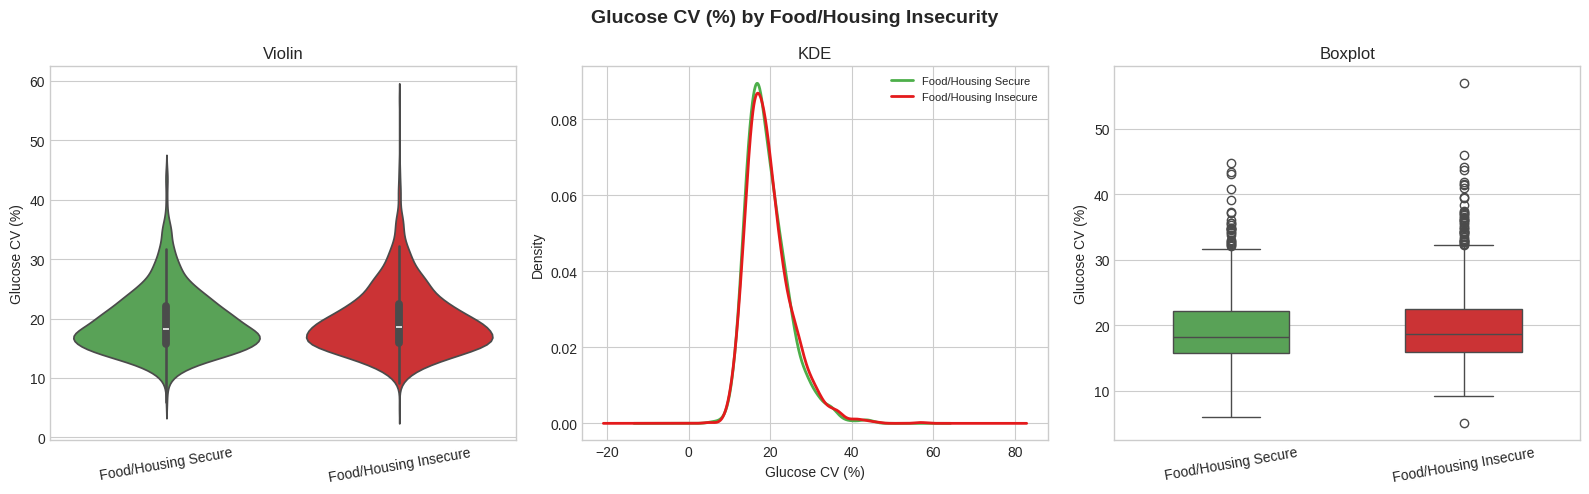

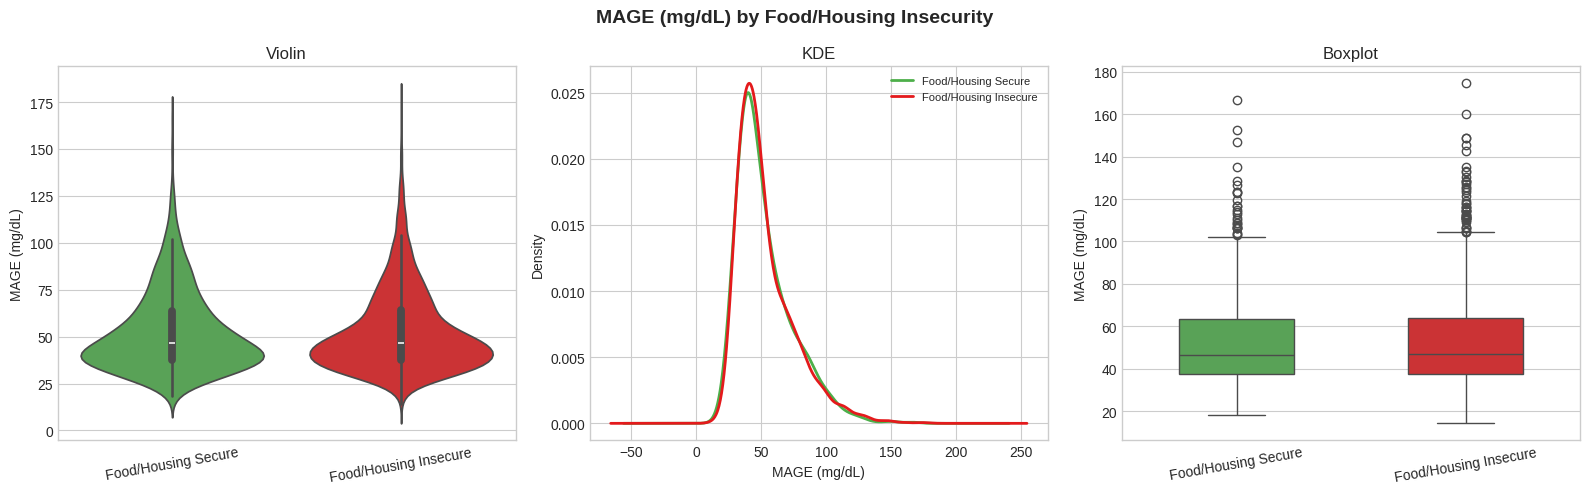

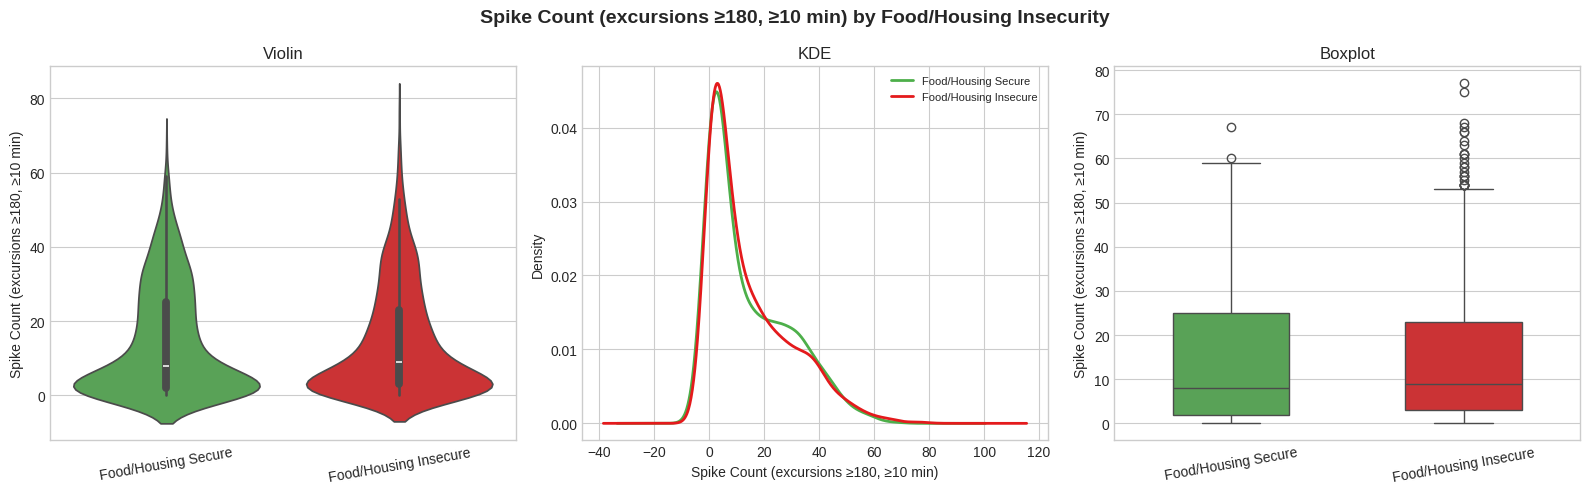

In [5]:
# ── 4. Distribution plots — spike metrics by insecurity ───────────
PRIMARY_METRICS = [
    ('tar_180',     'Time Above Range >180 (%)'),
    ('glucose_cv',  'Glucose CV (%)'),
    ('mage',        'MAGE (mg/dL)'),
    ('spike_count', 'Spike Count (excursions ≥180, ≥10 min)'),
]

for metric, label in PRIMARY_METRICS:
    sub = df.dropna(subset=[metric, 'insecurity_label'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{label} by Food/Housing Insecurity', fontsize=14, fontweight='bold')

    sns.violinplot(data=sub, x='insecurity_label', y=metric,
                   order=INSEC_ORDER, palette=INSEC_PAL, inner='box', ax=axes[0])
    axes[0].set_title('Violin'); axes[0].set_xlabel(''); axes[0].set_ylabel(label)
    axes[0].tick_params(axis='x', rotation=10)

    for status in INSEC_ORDER:
        vals = sub[sub['insecurity_label'] == status][metric]
        if len(vals) > 5:
            vals.plot.kde(ax=axes[1], label=status, linewidth=2,
                          color=INSEC_PAL[status])
    axes[1].set_title('KDE'); axes[1].set_xlabel(label); axes[1].legend(fontsize=8)

    sns.boxplot(data=sub, x='insecurity_label', y=metric,
                order=INSEC_ORDER, palette=INSEC_PAL, width=0.5, ax=axes[2])
    axes[2].set_title('Boxplot'); axes[2].set_xlabel(''); axes[2].set_ylabel(label)
    axes[2].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.show()

## 5. Primary Statistical Tests: All Spike Metrics vs Insecurity

Mann-Whitney U + Cohen's d for every spike metric. Bonferroni correction
applied for 12 simultaneous comparisons (α = 0.05/12 = 0.0042).

In [6]:
# ── 5. Comprehensive Mann-Whitney table ───────────────────────────
BONF_ALPHA = 0.05 / len(SPIKE_COLS)
print(f'Bonferroni threshold: α = {BONF_ALPHA:.4f}  ({len(SPIKE_COLS)} comparisons)\n')

result_rows = []
for col in SPIKE_COLS:
    sub  = df.dropna(subset=[col, 'food_housing_insecurity'])
    sec  = sub[sub['food_housing_insecurity'] == 0][col]
    ins  = sub[sub['food_housing_insecurity'] == 1][col]
    if len(sec) < 10 or len(ins) < 10:
        continue
    u, p = stats.mannwhitneyu(sec, ins, alternative='two-sided')
    d    = ((ins.mean() - sec.mean()) /
            np.sqrt((sec.std(ddof=1)**2 + ins.std(ddof=1)**2) / 2))
    result_rows.append({
        'metric':          col,
        'n_secure':        len(sec),
        'mean_secure':     round(sec.mean(), 3),
        'n_insecure':      len(ins),
        'mean_insecure':   round(ins.mean(), 3),
        'diff':            round(ins.mean() - sec.mean(), 3),
        'U':               round(u, 0),
        'p':               round(p, 5),
        'bonf_sig':        p < BONF_ALPHA,
        'cohens_d':        round(d, 4),
        'effect_size':     'small' if abs(d) < 0.5 else ('medium' if abs(d) < 0.8 else 'large'),
        'sig':             '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    })

res_df = pd.DataFrame(result_rows).sort_values('cohens_d', key=abs, ascending=False)
print(f'=== Spike Metrics: Food/Housing Secure vs Insecure (Bonferroni α={BONF_ALPHA:.4f}) ===')
print(res_df.to_string(index=False))

Bonferroni threshold: α = 0.0042  (12 comparisons)

=== Spike Metrics: Food/Housing Secure vs Insecure (Bonferroni α=0.0042) ===
             metric  n_secure  mean_secure  n_insecure  mean_insecure     diff          U     p  bonf_sig  cohens_d effect_size sig
         glucose_cv       881       19.403        1362         19.706    0.303 583758.000 0.279     False     0.056       small  ns
         glucose_sd       881       26.881        1362         27.346    0.465 585796.000 0.344     False     0.038       small  ns
            tar_250       881        3.446        1362          3.798    0.353 597764.000 0.866     False     0.027       small  ns
    spike_peak_mean       775      211.241        1217        210.589   -0.653 486927.000 0.220     False    -0.022       small  ns
               mage       881       52.815        1362         53.152    0.337 594949.000 0.738     False     0.015       small  ns
    spike_count_250       881        3.414        1362          3.359   -0.055 

## 6. Interaction Analysis: Insecurity × Study Group

NB12 found a significant reversal: insecure participants had **lower** mean glucose
in the Oral Med (−7.7 mg/dL, p=0.001) and Insulin (−12.9 mg/dL, p=0.012) groups.
Below we test whether this pattern replicates for spike metrics.

In [7]:
# ── 6a. Within-group tables for top 3 spike metrics ───────────────
TOP3 = res_df.nlargest(3, 'cohens_d', keep='first')['metric'].tolist()

for metric in TOP3:
    print(f'\n=== Within-group Secure vs Insecure | {metric} ===')
    print(f'{"Study Group":12s}  {"Secure":>8s}  {"Insecure":>8s}  '
          f'{"diff":>8s}  {"p":>8s}  sig')
    print('-' * 62)
    for grp in STUDY_GROUP_ORDER:
        sub = df[df['study_group_label'] == grp].dropna(
            subset=[metric, 'food_housing_insecurity'])
        s = sub[sub['food_housing_insecurity'] == 0][metric]
        i = sub[sub['food_housing_insecurity'] == 1][metric]
        if len(s) < 5 or len(i) < 5:
            continue
        u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
        diff = i.mean() - s.mean()
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp:12s}  {s.mean():8.2f}  {i.mean():8.2f}  '
              f'{diff:+8.2f}  {p:8.4f}  {sig}')


=== Within-group Secure vs Insecure | glucose_cv ===
Study Group     Secure  Insecure      diff         p  sig
--------------------------------------------------------------
Healthy          17.37     17.45     +0.08    0.8046  ns
Pre-DM           18.07     18.44     +0.37    0.2927  ns
Oral Med         21.20     20.70     -0.49    0.1748  ns
Insulin          25.61     25.37     -0.23    0.5891  ns

=== Within-group Secure vs Insecure | glucose_sd ===
Study Group     Secure  Insecure      diff         p  sig
--------------------------------------------------------------
Healthy          20.25     20.92     +0.67    0.2844  ns
Pre-DM           22.78     23.45     +0.67    0.3737  ns
Oral Med         32.49     30.19     -2.30    0.0039  **
Insulin          47.30     44.09     -3.21    0.0872  ns

=== Within-group Secure vs Insecure | tar_250 ===
Study Group     Secure  Insecure      diff         p  sig
--------------------------------------------------------------
Healthy           0.07

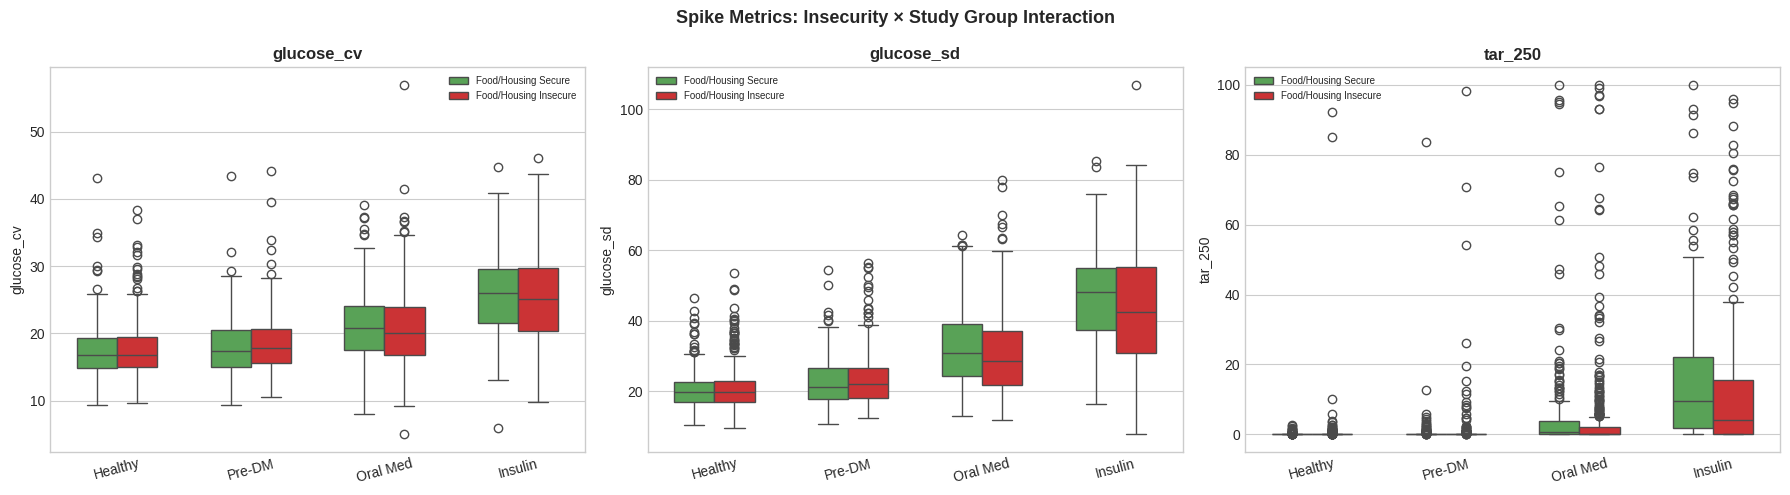

In [8]:
# ── 6b. Interaction boxplots (insecurity × study group) ────────────
fig, axes = plt.subplots(1, len(TOP3), figsize=(6 * len(TOP3), 5))
if len(TOP3) == 1:
    axes = [axes]
fig.suptitle('Spike Metrics: Insecurity × Study Group Interaction',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, TOP3):
    sub = df.dropna(subset=[metric, 'study_group_label', 'insecurity_label'])
    sns.boxplot(data=sub, x='study_group_label', y=metric,
                hue='insecurity_label',
                order=STUDY_GROUP_ORDER, hue_order=INSEC_ORDER,
                palette=INSEC_PAL, width=0.6, ax=ax)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='', fontsize=7)

plt.tight_layout()
plt.show()

**NB12 reversal check**: In NB12, food/housing insecure participants in Oral Med and
Insulin groups had *lower* mean glucose (counter-intuitive). Compare the direction
of the diff column above with the NB12 result:
- Oral Med: Insecure − Secure mean_glucose = −7.7 mg/dL (p=0.001)
- Insulin:  Insecure − Secure mean_glucose = −12.9 mg/dL (p=0.012)

Does the same reversal appear for spike metrics? Examine the sign of `diff` above for Oral Med and Insulin.

## 7. Subgroup: Healthy Participants Only

The cleanest test — no medication confounders to buffer or reverse the insecurity effect.

In [9]:
# ── 7. Healthy-only subgroup analysis ────────────────────────────
healthy = df[df['study_group_label'] == 'Healthy'].copy()
print(f'Healthy subgroup: n={len(healthy)}')
print(f'Insecurity rate in Healthy: {healthy["food_housing_insecurity"].mean()*100:.1f}%\n')

print(f'{"Metric":30s}  {"Secure mean":>11s}  {"Insec mean":>10s}  '
      f'{"d":>7s}  {"p":>8s}  sig')
print('-' * 75)
for col in SPIKE_COLS:
    sub = healthy.dropna(subset=[col, 'food_housing_insecurity'])
    s   = sub[sub['food_housing_insecurity'] == 0][col]
    i   = sub[sub['food_housing_insecurity'] == 1][col]
    if len(s) < 5 or len(i) < 5:
        continue
    u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
    d    = ((i.mean() - s.mean()) /
            np.sqrt((s.std(ddof=1)**2 + i.std(ddof=1)**2) / 2))
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{col:30s}  {s.mean():11.2f}  {i.mean():10.2f}  '
          f'{d:+7.3f}  {p:8.4f}  {sig}')

Healthy subgroup: n=759
Insecurity rate in Healthy: 57.2%

Metric                          Secure mean  Insec mean        d         p  sig
---------------------------------------------------------------------------
spike_count                            6.39        7.54   +0.127    0.0554  ns
spike_count_250                        0.23        0.52   +0.181    0.1899  ns
spike_duration_mean                   26.95       42.78   +0.107    0.3427  ns
spike_area                          5444.84    14683.40   +0.133    0.1261  ns
spike_peak_mean                      199.87      200.11   +0.020    0.4137  ns
tir                                   97.17       96.10   -0.163    0.5064  ns
tar_180                                1.94        3.07   +0.175    0.0506  ns
tar_250                                0.07        0.55   +0.113    0.0821  ns
tbr_70                                 0.88        0.83   -0.027    0.1024  ns
glucose_sd                            20.25       20.92   +0.119    0.2844

## 8. Sensitivity Comparison: Mean Glucose vs Spike Metrics

Which CGM outcome is most sensitive to the insecurity signal?

In [10]:
# ── 8. TAR vs mean glucose — sensitivity comparison ───────────────
print('=== Sensitivity: insecurity effect on different CGM outcomes ===')
print(f'{"Outcome":25s}  {"Secure mean":>12s}  {"Insec mean":>11s}  '
      f'{"p":>8s}  {"d":>8s}')
print('-' * 72)

outcomes = ['mean_glucose', 'tar_180', 'glucose_cv', 'mage', 'spike_count']
for outcome in outcomes:
    if outcome not in df.columns:
        continue
    sub = df.dropna(subset=[outcome, 'food_housing_insecurity'])
    s   = sub[sub['food_housing_insecurity'] == 0][outcome]
    i   = sub[sub['food_housing_insecurity'] == 1][outcome]
    u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
    d    = ((i.mean() - s.mean()) /
            np.sqrt((s.std(ddof=1)**2 + i.std(ddof=1)**2) / 2))
    print(f'{outcome:25s}  {s.mean():12.3f}  {i.mean():11.3f}  '
          f'{p:8.4f}  {d:+8.4f}')

=== Sensitivity: insecurity effect on different CGM outcomes ===
Outcome                     Secure mean   Insec mean         p         d
------------------------------------------------------------------------
mean_glucose                    135.170      135.471    0.7284   +0.0087
tar_180                          12.548       12.519    0.6656   -0.0014
glucose_cv                       19.403       19.706    0.2794   +0.0555
mage                             52.815       53.152    0.7380   +0.0154
spike_count                      14.482       14.460    0.7527   -0.0015


## 9. SDOH Spearman Correlations vs Spike Metrics

In [11]:
# ── 9. Continuous SDOH predictors vs spike metrics ────────────────
SDOH_COLS = [
    'neighborhood_safety_score', 'discrimination_score',
    'healthcare_access_barriers', 'dml_gap_composite',
    'food_housing_insecurity'
]
SPIKE_TARGET = ['tar_180', 'glucose_cv', 'mage', 'spike_count']

print(f'{"SDOH Predictor":30s}  {"Spike Metric":22s}  {"rho":>7}  {"p":>10}  {"n":>6}')
print('-' * 82)
for sdoh in SDOH_COLS:
    if sdoh not in df.columns:
        continue
    for col in SPIKE_TARGET:
        if col not in df.columns:
            continue
        sub = df[[sdoh, col]].dropna()
        if len(sub) < 30:
            continue
        rho, p = stats.spearmanr(sub[sdoh], sub[col])
        print(f'{sdoh:30s}  {col:22s}  {rho:+7.4f}  {p:10.4e}  {len(sub):6d}')

SDOH Predictor                  Spike Metric                rho           p       n
----------------------------------------------------------------------------------
neighborhood_safety_score       tar_180                 -0.0384  7.6761e-02    2120
neighborhood_safety_score       glucose_cv              -0.0491  2.3780e-02    2120
neighborhood_safety_score       mage                    -0.0371  8.7713e-02    2120
neighborhood_safety_score       spike_count             -0.0541  1.2779e-02    2120
discrimination_score            tar_180                 +0.0449  3.3524e-02    2243
discrimination_score            glucose_cv              +0.0432  4.1011e-02    2243
discrimination_score            mage                    +0.0502  1.7328e-02    2243
discrimination_score            spike_count             +0.0389  6.5723e-02    2243
healthcare_access_barriers      tar_180                 +0.0252  2.3219e-01    2243
healthcare_access_barriers      glucose_cv              +0.0294  1.6464e-01  

## 10. Summary Table & Export

In [12]:
# ── 10. Summary table by insecurity × study group ─────────────────
summary_rows = []
for grp in ['All'] + STUDY_GROUP_ORDER:
    sub = df if grp == 'All' else df[df['study_group_label'] == grp]
    for status, val in [('Secure', 0.0), ('Insecure', 1.0)]:
        s   = sub[sub['food_housing_insecurity'] == val]
        row = {'study_group': grp, 'insecurity_status': status, 'n': len(s)}
        for col in ['mean_glucose', 'tar_180', 'glucose_cv', 'mage', 'spike_count', 'tir']:
            if col in s.columns:
                row[f'{col}_mean'] = round(s[col].mean(), 3)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_df.to_csv(out_dir / '18_insecurity_spike_summary.csv', index=False)
print('\nSaved 18_insecurity_spike_summary.csv')

study_group insecurity_status    n  mean_glucose_mean  tar_180_mean  glucose_cv_mean  mage_mean  spike_count_mean  tir_mean
        All            Secure  881            135.170        12.548           19.403     52.815            14.482    86.719
        All          Insecure 1362            135.471        12.519           19.706     53.152            14.460    86.744
    Healthy            Secure  325            116.329         1.944           17.374     41.524             6.394    97.172
    Healthy          Insecure  434            119.466         3.065           17.453     42.528             7.539    96.104
     Pre-DM            Secure  218            125.335         5.085           18.071     46.289            11.156    93.897
     Pre-DM          Insecure  334            126.202         6.157           18.439     47.218            11.284    93.303
   Oral Med            Secure  260            152.177        21.987           21.196     63.151            23.946    77.658
   Oral 

## 11. Key Findings

- **Null across all spike metrics**: No spike metric is significantly associated with food/housing insecurity after Bonferroni correction (α=0.0042). All 12 metrics show negligible Cohen's d (max |d|=0.056 for glucose_cv, p=0.279). This extends the NB12 null finding — insecurity is not associated with glycemic burden regardless of whether the outcome is mean glucose, TAR, spike count, variability, or MAGE.

- **NB12 reversal replicates for spike metrics**: Within the Oral Med group, insecure participants have lower glucose_sd (30.19 vs 32.49, p=0.0039) and lower tar_250 (4.63 vs 5.40, p=0.0042) — the same counter-intuitive negative direction seen in NB12 for mean glucose (−7.7 mg/dL, p=0.001). The Insulin group shows a similar pattern for tar_250 (−3.73 mg/dL, p=0.020). This reversal is consistent across all CGM outcome definitions, strengthening the evidence that it reflects a genuine behavioral/clinical engagement artifact rather than measurement noise.

- **Healthy subgroup also null**: Among medication-free Healthy participants (n=759, 57.2% insecure), no spike metric reaches significance. The most notable trend is tar_180 (insecure: 3.07% vs secure: 1.94%, p=0.051, d=+0.175) — borderline but not significant, and the effect is small.

- **Insecurity binary lacks power regardless of outcome**: Side-by-side comparison across all five CGM outcomes shows essentially identical p-values and near-zero Cohen's d values (mean_glucose p=0.728 d=+0.009; tar_180 p=0.666 d=−0.001; glucose_cv p=0.279 d=+0.056; mage p=0.738 d=+0.015; spike_count p=0.753 d=−0.002). The combined binary flag simply does not discriminate glycemic risk at the cohort level.

- **SDOH Spearman: discrimination and DML gap show weak but consistent signals**: Discrimination score has a small positive correlation with spike metrics (tar_180 rho=+0.045, p=0.034; mage rho=+0.050, p=0.017). DML gap composite shows a small negative correlation (tar_180 rho=−0.066, p=0.002; spike_count rho=−0.063, p=0.003), likely reflecting that better diabetes management literacy partially buffers against hyperglycemia. These effects are much smaller than the disease severity gradient.

- **Modeling implication**: `food_housing_insecurity` should not be included as a predictor of spike metrics in any model that includes study group. The reversal in medicated groups makes it a source of confounding rather than signal.